In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

In [39]:
drug_col = "merged_umls_label"
disease_col = "merged_mondo_label"

# Prep Clinical Trials

In [5]:
clin_entities_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_clin.csv"
df_clin_entities = pd.read_csv(clin_entities_file)
df_clin_entities.head()

,nct_id,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,NCT03502551,suicidal|suicidal ideation|Suicide,suicidal|suicidal ideation|Suicide,-1|-1|-1,suicidal|suicidal ideation|Suicide,-1,suicidal|suicidal ideation|Suicide,-1|-1|-1,ketamine,Ketamine,C0022614,-1,Ketamine,C0022614
1,NCT05216770,laryngeal dystonia|voice tremor|Tremor,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644,spasmodic dystonia|voice tremor|obsolete rare ...,focal dystonia|-1,spasmodic dystonia|voice tremor|obsolete rare ...,MONDO:0000485|-1|MONDO:0017644|MONDO:0000477,Laryngeal sensory block with topical bupivacaine,Laryngeal sensory block with topical bupivacaine,-1,-1,Laryngeal sensory block with topical bupivacaine,-1
2,NCT03348735,np|subacute|pain|localized neuropathic pain|ch...,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667|MONDO:002...,np|subacute|obsolete disorder involving pain|l...,-1|-1,np|subacute|obsolete disorder involving pain|l...,-1|-1|MONDO:0021668|-1|MONDO:0021667,lidocaine|capsaicin|Lidocaine patch 5%,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811,-1,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,C0023660|C0006931|C0794811
3,NCT05995600,systemic lupus|definite|antiphospholipid syndr...,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...,systemic lupus erythematosus|definite|antiphos...,-1|-1|-1|-1|-1|brain ischemia,systemic lupus erythematosus|definite|antiphos...,MONDO:0007915|-1|-1|MONDO:0005098|-1|MONDO:000...,clopidogrel|warfarin|aspirin|Antiplatelet Drug,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1,-1,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,C0070166|C0043031|C0004057|-1
4,NCT02137993,schizophreniform disorder|schizoaffective diso...,schizophreniform disorder|schizophrenia|schizo...,MONDO:0001265|MONDO:0005090|MONDO:0005090,schizophreniform disorder|schizophrenia,-1|-1,schizophreniform disorder|schizophrenia,MONDO:0001265|MONDO:0005090,zyprexa|A-prexa,Zyprexa|A-prexa,C0527258|-1,olanzapine pamoate|OLANZapine|olanzapine pamoa...,Zyprexa|A-prexa|olanzapine pamoate|OLANZapine|...,C0527258|-1|C2698647|C0171023|C2726929


In [6]:
df_clin_entities.shape


(18609, 14)

In [7]:
clin_metadata_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_nct_docs_metadata_20240313.csv"
df_clin_metadata = pd.read_csv(clin_metadata_file)
df_clin_metadata = df_clin_metadata.drop_duplicates(subset=['nct_id'])

df_clin_metadata.head()

,nct_id,Neurological Disease,Disease Class,brief_title,study_official_title,brief_summary_description,start_date,completion_date,phase,study_type,overall_status,country_name,intervention_name,intervention_type
0,NCT03890861,"Dementia, Alzheimer Type",Neurodegenerative Diseases,Reducing African Americans' Alzheimer's Diseas...,Reducing African Americans' Alzheimer's Diseas...,The RAATE proposal is designed to determine th...,2019-08-09,2026-11-30,Not Applicable,Interventional,Recruiting,United States,Physical activity,Behavioral
6,NCT03060096,Depressive Symptoms,Psychiatry and Psychology Category,Stepped-Care Telehealth for Distress in Cancer...,Stepped-Care Telehealth for Distress in Cancer...,Mental health issues in post-treatment adult c...,2018-07-19,2023-12-31,Not Applicable,Interventional,Completed,United States,Severe Anxiety/depression: High Intensity Step...,Other
12,NCT04525742,Muscular Dystrophies,Neuromuscular Diseases,COVID-19 Pandemic and Parents of Disabled Chil...,COVID-19 Pandemic From the Perspective of Pare...,Pandemic period could affect the disabled chil...,2020-07-05,2020-09-15,Not Applicable,Interventional,Completed,Turkey,Difficulties lived by disabled children's pare...,Other
15,NCT02324634,Stroke,Central Nervous System Diseases,Early Electrical Stimulation to Prevent Compli...,Early Electrical Stimulation to the Wrist Exte...,Stroke is the largest cause of adult disabilit...,2015-06-01,2017-11-30,Not Applicable,Interventional,Unknown status,United Kingdom,NeuroTrac Rehab dual channel device,Device
18,NCT06036368,Essential Tremor,Central Nervous System Diseases,Study to Evaluate Safety and Efficacy of Peron...,"6-weeks, Open-label, Single-Site Study to Eval...","This is a 6-week exploratory clinical study, d...",2023-09-15,2024-06-30,Not Applicable,Interventional,Not yet recruiting,Czechia,Peroneal electrical transcutaneous neuromodula...,Device


In [8]:
df_clin_metadata.shape

(46376, 14)

In [10]:
df_clin_entities_metadata = df_clin_entities.merge(df_clin_metadata, on="nct_id", how="left")[['nct_id',drug_col,disease_col, 'start_date', 'completion_date', 'overall_status', 'phase']]
df_clin_entities_metadata

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4
3,NCT05995600,clopidogrel|Warfarin|Aspirin|Antiplatelet Drug,systemic lupus erythematosus|definite|antiphos...,2023-12-31,2028-08-31,Not yet recruiting,Phase 4
4,NCT02137993,Zyprexa|A-prexa|olanzapine pamoate|OLANZapine|...,schizophreniform disorder|schizophrenia,2012-03-31,2013-05-31,Completed,Phase 4
...,...,...,...,...,...,...,...
18604,NCT05617508,nicotinamide ribonucleoside,Alzheimer disease,2022-11-22,2025-03-31,Recruiting,Phase 2
18605,NCT02470780,rifaximin,Parkinson disease|small intestinal bacterial o...,2015-12-31,2017-08-31,Completed,Phase 2/Phase 3
18606,NCT05485987,Vatiquinone,Friedreich ataxia,2022-10-13,2024-10-05,"Active, not recruiting",Phase 2
18607,NCT05431595,Valproic Acid|Haloperidol|Chlorpromazine|neuro...,delirium|cancer,2022-07-19,2027-02-02,Enrolling by invitation,Phase 2/Phase 3


In [13]:
list(df_clin_entities_metadata[df_clin_entities_metadata['nct_id']=='NCT00383448'].merged_umls_label)

['Mofetil, Mycophenolate|Infecto Flu|Monomethyl fumarate|clofarabine']

In [23]:
df_clin_entities_metadata_flat_drug = (
    df_clin_entities_metadata
    .assign(drug_term_umls_norm=df_clin_entities_metadata[drug_col].astype(str).str.split("|"))
    .explode("drug_term_umls_norm")
)

In [24]:
df_clin_entities_metadata_flat_drug.head()

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase,drug_term_umls_norm
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2,Ketamine
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1,Laryngeal sensory block with topical bupivacaine
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Lidocaine
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Capsaicin
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,lidocaine 0.05 MG/MG Medicated Patch


In [25]:
df_clin_entities_metadata_flat_drug.drug_term_umls_norm.nunique()

12904

In [26]:
df_clin_entities_metadata_flat_drug[df_clin_entities_metadata_flat_drug['drug_term_umls_norm'].str.contains("QUEtiapine") & df_clin_entities_metadata_flat_drug['phase'].str.contains("Phase 4")]

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase,drug_term_umls_norm
1355,NCT02305823,ARIPiprazole|first generation antipsychotics|Z...,first episode|schizophrenia|first episode of n...,2005-10-31,2014-05-31,Completed,Phase 4,QUEtiapine
1801,NCT05481957,OLANZapine|vortioxetine|mood stabilizer|mood|Q...,bipolar disorder|depressive disorder|hypomania,2022-03-01,2023-08-15,Completed,Phase 4,QUEtiapine
2122,NCT02845453,QUEtiapine,use|substance use disorder|substance use disor...,2017-01-20,2021-04-07,Completed,Phase 4,QUEtiapine
3036,NCT02526030,ARIPiprazole|sga|first generation antipsychoti...,first episode|schizophrenia|first episode of n...,2008-10-31,2015-06-30,Completed,Phase 4,QUEtiapine
3039,NCT01587066,Valproic Acid|mood|QUEtiapine|Lamotrigine|mood...,depressive disorder|mild to moderate depressiv...,2010-08-31,2011-09-30,Withdrawn,Phase 4,QUEtiapine
...,...,...,...,...,...,...,...,...
17132,NCT00156715,Seroquel|QUEtiapine|QUEtiapine fumarate,active substance use disorder|substance abuse|...,2004-03-31,2008-10-31,Completed,Phase 4,QUEtiapine fumarate
17176,NCT01662297,Trazodone|QUEtiapine,psychiatric disorder|dually diagnosed|insomnia...,2012-07-31,2015-10-31,Terminated,Phase 4,QUEtiapine
17430,NCT00466609,Fluoxetine|QUEtiapine|Clomipramine|Clomipramin...,obsessive-compulsive disorder,2007-05-31,2010-04-30,Completed,Phase 4,QUEtiapine
17853,NCT00550394,Topiramate|QUEtiapine|quetiapine and placebo,alcohol|alcohol abuse|bipolar disorder,2008-04-30,2010-06-30,Completed,Phase 4,QUEtiapine


In [27]:
# Ensure date columns are in datetime format
df_clin_entities_metadata_flat_drug["start_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["start_date"], errors="coerce"
)
df_clin_entities_metadata_flat_drug["completion_date"] = pd.to_datetime(
    df_clin_entities_metadata_flat_drug["completion_date"], errors="coerce"
)

# Compute duration in days
df_clin_entities_metadata_flat_drug["trial_duration_days"] = (
    df_clin_entities_metadata_flat_drug["completion_date"]
    - df_clin_entities_metadata_flat_drug["start_date"]
).dt.days

# Remove negative or invalid durations
df_clin_entities_metadata_flat_drug.loc[
    df_clin_entities_metadata_flat_drug["trial_duration_days"] < 0,
    "trial_duration_days"
] = np.nan

# Convert to years (rounded to 2 decimals)
df_clin_entities_metadata_flat_drug["trial_duration_years"] = (
    df_clin_entities_metadata_flat_drug["trial_duration_days"] / 365.25
).round(2)

In [29]:
df_clin_entities_metadata_flat_drug.head()

,nct_id,merged_umls_label,merged_mondo_label,start_date,completion_date,overall_status,phase,drug_term_umls_norm,trial_duration_days,trial_duration_years
0,NCT03502551,Ketamine,suicidal|suicidal ideation|Suicide,2019-04-01,2019-06-30,Withdrawn,Phase 2,Ketamine,90.0,0.25
1,NCT05216770,Laryngeal sensory block with topical bupivacaine,spasmodic dystonia|voice tremor|obsolete rare ...,2022-03-24,2026-08-31,Recruiting,Early Phase 1,Laryngeal sensory block with topical bupivacaine,1621.0,4.44
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Lidocaine,868.0,2.38
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,Capsaicin,868.0,2.38
2,NCT03348735,Lidocaine|Capsaicin|lidocaine 0.05 MG/MG Medic...,np|subacute|obsolete disorder involving pain|l...,2018-12-03,2021-04-19,Terminated,Phase 4,lidocaine 0.05 MG/MG Medicated Patch,868.0,2.38


In [30]:
def phase_to_num(s: str) -> float:
    """
    Map phase strings (Arabic only) to numeric ranks:
      Not Applicable -> 0.0
      Early Phase 1 / Phase 0 -> 0.75
      Phase x        -> x.0
      Phase x/y      -> (min(x,y) + 0.5)
      Phase 2a/b     -> 2.0 (treat a/b as that phase)
    Unknown/missing -> NaN
    """
    if not isinstance(s, str) or not s.strip():
        return np.nan
    t = s.strip()

    if re.search(r"not\s*applicable|observational", t, re.I):
        return 0.0
    if re.search(r"early\s*phase\s*1|phase\s*0", t, re.I):
        return 0.75

    # Extract all Arabic phase numbers present
    nums = [int(x) for x in re.findall(r"Phase\s*([0-4])(?:\s*[abAB])?", t, flags=re.I)]
    if len(nums) >= 2:
        a, b = sorted(nums[:2])
        return a + 0.5
    if len(nums) == 1:
        return float(nums[0])

    return np.nan

def summarize_trials_by_drug_simple(
    df: pd.DataFrame,
    drug_col: str = "drug_term_umls_norm",
    nct_col: str = "nct_id",
    date_col: str = "start_date",
    phase_col: str = "phase",
    duration_col: str = "trial_duration_years",
    status_col: str = "overall_status",
):
    """
    For each drug, return:
      - number of unique trials
      - min & max phase (with NCT + start year; min ignores 'Not Applicable')
      - median trial duration (years)
      - shortest (only among COMPLETED trials) & longest trial durations (years) with NCT IDs
    """

    # --- Prepare exploded dataset ---
    use_cols = [c for c in [nct_col, drug_col, date_col, phase_col, duration_col, status_col] if c in df.columns]
    w = df[use_cols].copy()

    # explode pipe-separated drugs
    w = w[w[drug_col].notna()].copy()
    w[drug_col] = w[drug_col].astype(str).str.split("|")
    w = w.explode(drug_col)
    w[drug_col] = w[drug_col].astype(str).str.strip()
    w = w[(w[drug_col].notna()) & (w[drug_col] != "") & (w[drug_col].str.lower() != "nan")].copy()

    # parse dates & helpers
    w[date_col] = pd.to_datetime(w[date_col], errors="coerce")
    w["start_year"] = w[date_col].dt.year
    w["phase_num"] = w[phase_col].apply(phase_to_num)

    # --- Aggregates ---
    n_trials = w.groupby(drug_col)[nct_col].nunique().rename("n_unique_trials")
    median_duration = (
        w.groupby(drug_col)[duration_col].median().rename("median_trial_duration_years")
        if duration_col in w.columns else pd.Series(dtype=float, name="median_trial_duration_years")
    )

    # --- Shortest (Completed) trial ---
    if duration_col in w.columns:
        completed_mask = w[status_col].str.lower().eq("completed") if status_col in w.columns else pd.Series(True, index=w.index)
        w_completed = w[completed_mask & w[duration_col].notna()]

        shortest_info = (
            w_completed
            .sort_values([drug_col, duration_col, date_col])
            .drop_duplicates(subset=[drug_col], keep="first")
            [[drug_col, nct_col, duration_col]]
            .rename(columns={
                nct_col: "shortest_trial_nct_id",
                duration_col: "shortest_trial_years"
            })
        )

        # --- Longest trial (all statuses) ---
        longest_info = (
            w.dropna(subset=[duration_col])
            .sort_values([drug_col, duration_col, date_col], ascending=[True, False, True])
            .drop_duplicates(subset=[drug_col], keep="first")
            [[drug_col, nct_col, duration_col]]
            .rename(columns={
                nct_col: "longest_trial_nct_id",
                duration_col: "longest_trial_years"
            })
        )
    else:
        shortest_info = pd.DataFrame(columns=[drug_col, "shortest_trial_nct_id", "shortest_trial_years"])
        longest_info  = pd.DataFrame(columns=[drug_col, "longest_trial_nct_id",  "longest_trial_years"])

    # --- MAX phase (earliest start if tie) ---
    valid_max = w[w["phase_num"].notna()].copy()
    max_info = (
        valid_max.loc[valid_max.groupby(drug_col)["phase_num"].transform("max").eq(valid_max["phase_num"])]
        .sort_values([drug_col, date_col])
        .drop_duplicates(subset=[drug_col])
        [[drug_col, nct_col, phase_col, "start_year"]]
        .rename(columns={
            nct_col: "max_phase_nct_id",
            phase_col: "max_phase",
            "start_year": "max_phase_start_year"
        })
    )

    # --- MIN phase (ignore ≤0 / Not Applicable) ---
    valid_min = w[(w["phase_num"].notna()) & (w["phase_num"] > 0.0)].copy()
    min_info = (
        valid_min.loc[valid_min.groupby(drug_col)["phase_num"].transform("min").eq(valid_min["phase_num"])]
        .sort_values([drug_col, date_col])
        .drop_duplicates(subset=[drug_col])
        [[drug_col, nct_col, phase_col, "start_year"]]
        .rename(columns={
            nct_col: "min_phase_nct_id",
            phase_col: "min_phase",
            "start_year": "min_phase_start_year"
        })
    )

    # --- Earliest trial overall (any phase) ---
    # Tie-break: if multiple rows share the earliest date, keep the highest phase_num
    earliest_info = (
        w.dropna(subset=[date_col])                # need a date to define "earliest"
         .sort_values([drug_col, date_col, "phase_num"], ascending=[True, True, False])
         .drop_duplicates(subset=[drug_col], keep="first")
         [[drug_col, nct_col, phase_col, "start_year"]]
         .rename(columns={
             nct_col: "earliest_trial_nct_id",
             phase_col: "earliest_trial_phase",
             "start_year": "earliest_trial_start_year"
         })
    )

    # --- Combine everything ---
    out = (
        n_trials.to_frame()
        .join(median_duration, how="left")
        .reset_index()
        .merge(min_info, on=drug_col, how="left")
        .merge(max_info, on=drug_col, how="left")
        .merge(earliest_info, on=drug_col, how="left")       
        .merge(shortest_info, on=drug_col, how="left")
        .merge(longest_info, on=drug_col, how="left")
        .rename(columns={drug_col: "drug_term_umls_norm"})
        .sort_values(["max_phase_start_year", "max_phase", "n_unique_trials"],
                     ascending=[True, False, False],
                     na_position="last")
    )

    # Round durations for nice display
    for c in ["median_trial_duration_years", "shortest_trial_years", "longest_trial_years"]:
        if c in out.columns:
            out[c] = out[c].astype(float).round(2)

    return out

In [31]:
clinical_drug_summary = summarize_trials_by_drug_simple(df_clin_entities_metadata_flat_drug)
clinical_drug_summary.head()

,drug_term_umls_norm,n_unique_trials,median_trial_duration_years,min_phase_nct_id,min_phase,min_phase_start_year,max_phase_nct_id,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years
5365,PLACEBO,330,2.00,NCT02102113,Early Phase 1,2014.0,NCT00659919,Phase 4,2000,NCT00006289,Phase 2,2000,NCT03783312,0.14,NCT00676715,15.31
6128,Risperidone,295,2.25,NCT03790085,Early Phase 1,2018.0,NCT00469664,Phase 4,2000,NCT00249223,Phase 3,2000,NCT00645502,0.08,NCT02535156,12.00
5091,OLANZapine,226,2.33,NCT00287352,Phase 1,2005.0,NCT00469664,Phase 4,2000,NCT00469664,Phase 4,2000,NCT02804568,0.17,NCT00512070,18.42
629,ARIPiprazole,219,2.50,NCT00089440,Phase 1,2004.0,NCT00469664,Phase 4,2000,NCT00041678,Phase 3,2000,NCT01552772,0.25,NCT00320671,10.00
5884,QUEtiapine,196,2.25,NCT04280965,Early Phase 1,2019.0,NCT00469664,Phase 4,2000,NCT00469664,Phase 4,2000,NCT05793632,0.12,NCT00297947,9.83


<Axes: >

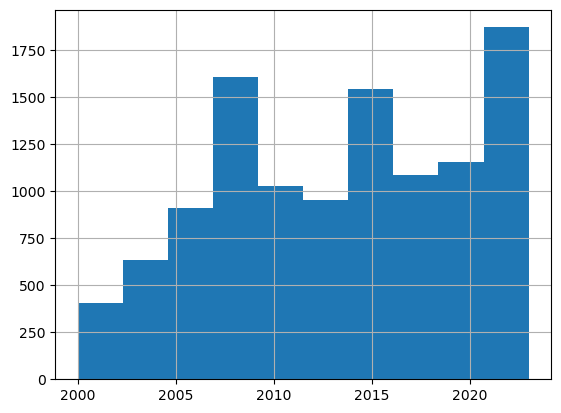

In [32]:
clinical_drug_summary.min_phase_start_year.hist()

<Axes: >

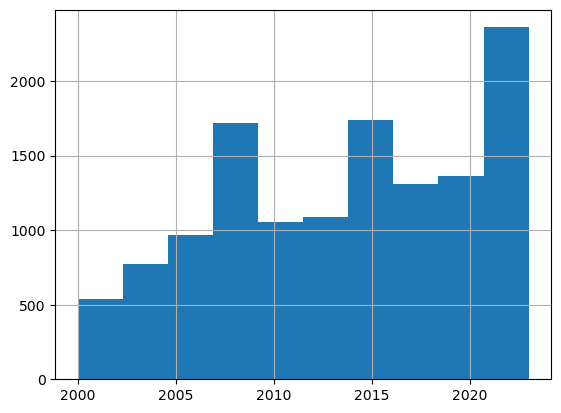

In [33]:
clinical_drug_summary.max_phase_start_year.hist()

In [34]:
clinical_drug_summary.to_csv("out/all_drugs_clinical_min_max_phase.csv")

# Prep Preclinical Articles

In [35]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations.csv"
preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]
preclin_dataset['animal_sex'] = preclin_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))
preclin_dataset.head()


/tmp/ipykernel_464278/274797946.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preclin_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm', 'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size', 'animal_species','animal_sex','animal_age','animal_strain','animal_number', 'assay_type', 'first_author_country']]


,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin|Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled
4,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,beta-adrenergic receptor blocking agent|Nadolo...,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, dog",male,not reported,Mongrel,not reported,"Molecular & Cellular, Physiology",unlabeled


In [36]:
primekg_cleaned = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv")
preclin_dataset = preclin_dataset.merge(primekg_cleaned[['PMID','merged_mondo_label','merged_umls_label']], on="PMID", how="left")


In [37]:
primekg_cleaned.shape

(540999, 14)

In [38]:
preclin_dataset.shape

(340380, 17)

In [40]:
preclin_dataset = (
    preclin_dataset
    .assign(drug_term_umls_norm=preclin_dataset[drug_col].astype(str).str.split("|"))
    .explode("drug_term_umls_norm")
)
preclin_dataset.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,animal_age,animal_strain,animal_number,assay_type,first_author_country,merged_mondo_label,merged_umls_label
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,not reported,Sprague-Dawley,not reported,Histology,unlabeled,ischemic disease,Lactate
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported,"Behavioral, Molecular & Cellular",unlabeled,metabolic acidosis|poisoning,Fomepizole
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,not reported,not reported,not reported,Molecular & Cellular,unlabeled,hypochromic anemia,Ethanol
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled,epilepsy,Phenytoin|Pentobarbital
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,not reported,not reported,2.0,not reported,unlabeled,epilepsy,Phenytoin|Pentobarbital


In [41]:
preclin_dataset.drug_term_umls_norm.nunique()

196443

## Merge preclin to clinical

In [42]:
preclin_dataset_to_clinical = preclin_dataset.merge(clinical_drug_summary, on="drug_term_umls_norm", how="left")
preclin_dataset_to_clinical = preclin_dataset_to_clinical[preclin_dataset_to_clinical["n_unique_trials"].notna()]

In [55]:
preclin_dataset.PMID.nunique()

340380

In [43]:
preclin_dataset_to_clinical.PMID.nunique()

198815

In [44]:
preclin_dataset_to_clinical.drug_term_umls_norm.nunique()

4545

In [45]:
def classify_translation(max_phase):
    if max_phase == "Phase 4":
        return "approved"
    else:
        return "failed"


preclin_dataset_to_clinical['study_classification'] = preclin_dataset_to_clinical['max_phase'].apply(lambda x:classify_translation(x))

In [46]:
preclin_dataset_to_clinical.shape

(325247, 33)

In [47]:
preclin_dataset_to_clinical.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,...,Phase 3,2020.0,NCT00319345,Phase 2/Phase 3,2003.0,NCT01455376,0.25,NCT02776488,5.75,failed
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,Phase 4,2013.0,NCT00016679,Phase 1,2001.0,NCT01054859,0.00,NCT00816231,13.12,approved
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,Phase 4,2003.0,NCT01878578,Phase 1,2002.0,NCT02283827,0.16,NCT04573803,7.00,approved
4,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,Phase 3,2002.0,NCT00622570,Phase 3,2002.0,NaN,NaN,NCT00622570,5.59,failed
5,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,Propranolol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, dog",male,...,Phase 4,2003.0,NCT00236561,Phase 3,2001.0,NCT00093860,0.41,NCT00611871,8.00,approved


In [48]:
preclin_dataset_to_clinical.columns

Index(['PMID', 'title', 'disease_term_mondo_norm', 'drug_term_umls_norm',
       'rigor_blinding', 'rigor_randomization', 'rigor_welfare', 'sample_size',
       'animal_species', 'animal_sex', 'animal_age', 'animal_strain',
       'animal_number', 'assay_type', 'first_author_country',
       'merged_mondo_label', 'merged_umls_label', 'n_unique_trials',
       'median_trial_duration_years', 'min_phase_nct_id', 'min_phase',
       'min_phase_start_year', 'max_phase_nct_id', 'max_phase',
       'max_phase_start_year', 'earliest_trial_nct_id', 'earliest_trial_phase',
       'earliest_trial_start_year', 'shortest_trial_nct_id',
       'shortest_trial_years', 'longest_trial_nct_id', 'longest_trial_years',
       'study_classification'],
      dtype='object')

In [49]:
def count_unique_from_pipe_column(df, column):
    """
    Count unique items and their frequencies in a DataFrame column containing '|' separated values.

    Returns:
        total_unique (int): total number of unique non-empty terms
        freq_df (pd.DataFrame): columns ['term', 'n_articles']
                               where 'n_articles' = number of unique PMIDs (rows) mentioning that term
    """
    import pandas as pd

    # explode values
    all_items = (
        df[[column, "PMID"]]
        .dropna(subset=[column])
        .assign(**{column: df[column].astype(str).str.split("|")})
        .explode(column)
    )
    all_items[column] = all_items[column].str.strip()
    all_items = all_items[all_items[column] != ""]

    # count how many distinct PMIDs mention each term
    freq = (
        all_items.groupby(column)["PMID"]
        .nunique()
        .reset_index(name="n_articles")
        .sort_values("n_articles", ascending=False)
    )

    total_unique = freq.shape[0]
    return total_unique, freq

In [50]:
total_unique, freq = count_unique_from_pipe_column(preclin_dataset_to_clinical, "drug_term_umls_norm")

In [51]:
total_unique

4545

In [52]:
preclin_dataset_to_clinical

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,rigor_blinding,rigor_randomization,rigor_welfare,sample_size,animal_species,animal_sex,...,max_phase,max_phase_start_year,earliest_trial_nct_id,earliest_trial_phase,earliest_trial_start_year,shortest_trial_nct_id,shortest_trial_years,longest_trial_nct_id,longest_trial_years,study_classification
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rat,male,...,Phase 3,2020.0,NCT00319345,Phase 2/Phase 3,2003.0,NCT01455376,0.25,NCT02776488,5.75,failed
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,rabbit,not-reported,...,Phase 4,2013.0,NCT00016679,Phase 1,2001.0,NCT01054859,0.00,NCT00816231,13.12,approved
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,Phase 4,2003.0,NCT01878578,Phase 1,2002.0,NCT02283827,0.16,NCT04573803,7.00,approved
4,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Pentobarbital,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,rat,not-reported,...,Phase 3,2002.0,NCT00622570,Phase 3,2002.0,NaN,NaN,NCT00622570,5.59,failed
5,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,Propranolol,blinding-not-reported,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, dog",male,...,Phase 4,2003.0,NCT00236561,Phase 3,2001.0,NCT00093860,0.41,NCT00611871,8.00,approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871091,38979126,Dexamethasone alleviates etomidate-induced myo...,early myoclonic encephalopathy,Dexamethasone,blinding-not-reported,randomization-present,welfare-present,sample-size-present,rat,male,...,Phase 4,2005.0,NCT00088166,Phase 3,2004.0,NCT03194594,0.11,NCT01868269,18.03,approved
871097,38979170,Blocking HXA3-mediated neutrophil elastase rel...,streptococcal pneumonia|sp lung infection|sp|c...,"8,11,14-Eicosatrienoic acid",blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,"cat, mouse",not-reported,...,Not Applicable,2022.0,NCT05342844,Not Applicable,2022.0,NCT05342844,1.12,NCT05342844,1.12,failed
871099,38979288,Substance P receptor signaling contributes to ...,infectious disease,sp receptor antagonist,blinding-not-reported,randomization-not-reported,welfare-present,sample-size-not-reported,"cat, mouse",both,...,Early Phase 1,2021.0,NCT03035838,Early Phase 1,2021.0,NaN,NaN,NCT03035838,1.41,failed
871100,38979291,RNAi-mediated silencing of SOD1 profoundly ext...,amyotrophic lateral sclerosis,Small interfering RNA,blinding-present,randomization-not-reported,welfare-not-reported,sample-size-not-reported,"cat, mouse",both,...,Phase 3,2013.0,NCT01960348,Phase 3,2013.0,NCT02595983,1.27,NCT01960348,3.75,failed


In [53]:
preclin_dataset_to_clinical.to_csv("data/preclin_dataset_to_clinical.csv", index=False)

# Drug studies over time

In [56]:
PRECLINICAL_ANNOTATIONS_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
preclin_data = pd.read_csv(PRECLINICAL_ANNOTATIONS_PATH)
preclin_data = preclin_data.drop_duplicates(subset=["PMID"])
preclin_data.shape

(540999, 14)

In [57]:
PRECLINICAL_METADATA_PATH = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/02_animal_study_classification/data/animal_studies/full_pubmed_filtered_animal_6002827_metadata.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/03_IE_ner/data/animal_studies_with_drug_disease/animal_studies_metadata_595768.csv"
metadata_df_year = pd.read_csv(PRECLINICAL_METADATA_PATH)[['PMID','year']]
metadata_df_year = metadata_df_year.drop_duplicates(subset=['PMID'])

preclin_data = preclin_data.merge(metadata_df_year, on="PMID", how="left")

In [63]:
preclin_data_for_timeline = preclin_data[['PMID','merged_umls_label','year']]
preclin_data_for_timeline = preclin_data_for_timeline.dropna(subset=["year"])
preclin_data_for_timeline["year"] = preclin_data_for_timeline["year"].astype(int)
preclin_data_for_timeline

,PMID,merged_umls_label,year
0,31733831,isorhynchophylline,2020
1,31733833,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",2020
2,31733925,HLA-G2 Isoform|g2,2020
3,31733940,Minocycline,2020
4,31734027,Tadalafil,2019
...,...,...,...
540994,57667,Interferon,1976
540995,57929,cy|Cyclophosphamide,1976
540996,58073,rifazone-82|Rifamycins|Rifamycin SV,1976
540997,58789,diethyphen|Guanethidine|Papaverine|Euphylline,1975


In [72]:
preclin_data_for_timeline["merged_umls_label"] = (
    preclin_data_for_timeline["merged_umls_label"]
    .astype(str)
    .str.split("|")
)

preclin_data_for_timeline = preclin_data_for_timeline.explode("merged_umls_label", ignore_index=True)


preclin_data_for_timeline["merged_umls_label"] = preclin_data_for_timeline["merged_umls_label"].str.strip()
preclin_data_for_timeline = preclin_data_for_timeline[preclin_data_for_timeline["merged_umls_label"] != ""]
preclin_data_for_timeline = preclin_data_for_timeline[
    preclin_data_for_timeline["merged_umls_label"].str.len() > 2
]
preclin_data_for_timeline.shape

(1444148, 3)

In [73]:
pivot = (
    preclin_data_for_timeline
    .pivot_table(
        index="merged_umls_label",
        columns="year",
        values="PMID",
        aggfunc="nunique",   # count unique PMIDs per year
        fill_value=0
    )
)
pivot["Total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("Total", ascending=False)
pivot

year,1849,1869,1870,1904,1906,1908,1909,1911,1912,1913,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Total
merged_umls_label,,,,,,,,,,,,,,,,,,,,,
Dexamethasone,0,0,0,0,0,0,0,0,0,0,...,184,204,210,198,224,225,168,189,9,5801
Acetylcysteine,0,0,0,0,0,0,0,0,0,0,...,199,215,214,228,208,203,192,183,4,4557
NG-Nitroarginine Methyl Ester,0,0,0,0,0,0,0,0,0,0,...,86,85,88,93,65,62,42,35,0,4304
Sirolimus,0,0,0,0,0,0,0,0,0,0,...,221,256,271,295,302,262,228,229,10,4104
Doxorubicin,0,0,0,0,0,0,0,0,0,0,...,190,252,270,252,226,239,218,188,9,4019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
day 1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
"day, respectively, of 4,4'-sulfonylbisformanilide",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
dayil-11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [74]:
pivot.to_csv("./out/all_drugs_articles_timeline.csv")